In [3]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, *cwd.parents):
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw")


PROJECT_ROOT = resolve_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

file_map = {
    "antispiegel": "antispiegel_clean.csv",
    "compact": "compact_clean.csv",
    "nius": "nius_clean.csv",
    "rt_de": "rt_de_clean.csv",
    "tagesschau": "tagesschau_clean.csv",
    "tichys": "tichys_clean.csv",
}

datasets = {}
for name, filename in file_map.items():
    path = RAW_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {name}: {path}")
    datasets[name] = pd.read_csv(path)
    print(f"{name:<12} {datasets[name].shape} <- {path}")

# Optional combined corpus dataframe
overall_df = pd.concat(datasets.values(), ignore_index=True)
print("overall_df  ", overall_df.shape)

antispiegel  (589, 4) <- /Users/katinkakurz/projects/Thesis/data/raw/antispiegel_clean.csv
compact      (1564, 4) <- /Users/katinkakurz/projects/Thesis/data/raw/compact_clean.csv
nius         (3269, 4) <- /Users/katinkakurz/projects/Thesis/data/raw/nius_clean.csv
rt_de        (4560, 4) <- /Users/katinkakurz/projects/Thesis/data/raw/rt_de_clean.csv
tagesschau   (6320, 4) <- /Users/katinkakurz/projects/Thesis/data/raw/tagesschau_clean.csv
tichys       (2946, 4) <- /Users/katinkakurz/projects/Thesis/data/raw/tichys_clean.csv
overall_df   (19248, 4)


In [4]:
overall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19248 entries, 0 to 19247
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    19248 non-null  str  
 1   Title   19248 non-null  str  
 2   Text    19246 non-null  str  
 3   source  19248 non-null  str  
dtypes: str(4)
memory usage: 601.6 KB


In [5]:
# Convert Date to datetime in the combined dataframe
overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce")

overall_df["Date"].dtype

dtype('<M8[us]')

In [6]:
# Add a unique ID column for each row in overall_df
overall_df = overall_df.reset_index(drop=True)
overall_df["row_id"] = overall_df.index + 1

# Optional quick check
print("Unique IDs:", overall_df["row_id"].is_unique)
overall_df[["row_id", "Date", "Title"]].head()

Unique IDs: True


,row_id,Date,Title
0,1,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...
1,2,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...
2,3,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...
3,4,2025-08-02,Fordert Russland wirklich die Vernichtung alle...
4,5,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...


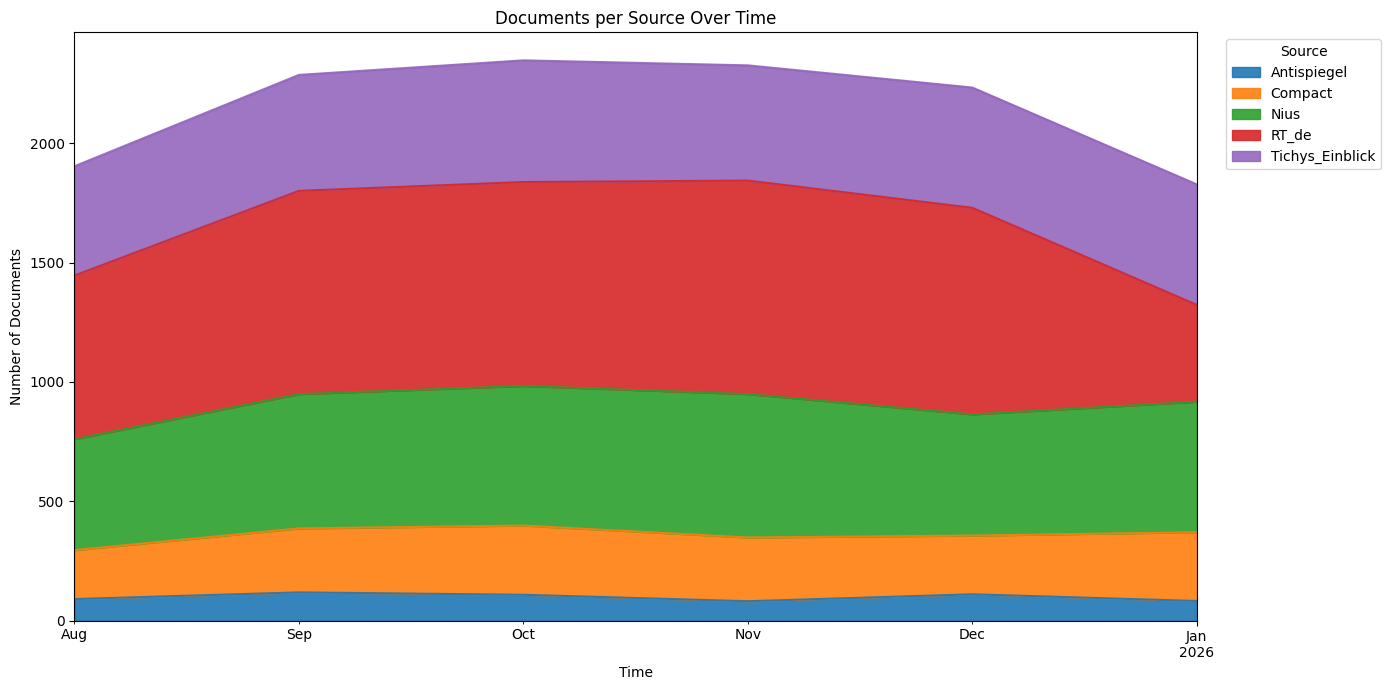

source,Antispiegel,Compact,Nius,RT_de,Tichys_Einblick
period,,,,,
2025-08-01,90,205,465,686,458
2025-09-01,118,268,563,852,486
2025-10-01,108,290,585,855,510
2025-11-01,81,267,601,895,483
2025-12-01,110,246,508,866,504


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Assumes you already have `overall_df` with columns: Date, source
df_plot = overall_df.copy()

# Parse date and keep valid rows
df_plot["Date"] = pd.to_datetime(df_plot["Date"], errors="coerce", utc=True).dt.tz_localize(None)
df_plot = df_plot.dropna(subset=["Date", "source"])

# Choose granularity: "D" (day), "W" (week), "M" (month)
freq = "M"

# Count docs per source over time
count_df = (
    df_plot
    .assign(period=df_plot["Date"].dt.to_period(freq).dt.to_timestamp())
    .groupby(["period", "source"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot stacked area chart
ax = count_df.plot.area(figsize=(14, 7), alpha=0.9)
ax.set_title("Documents per Source Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Number of Documents")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

count_df.head()


## BERTopic

In [7]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [8]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [9]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)


2 0.9


In [10]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)


cwd: /Users/katinkakurz/projects/Thesis/data preprocessing
project root added: /Users/katinkakurz/projects/Thesis


In [11]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=overall_df,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="row_id",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-10 14:35:15,028 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/600 [00:00<?, ?it/s]

2026-03-10 14:36:59,908 - BERTopic - Embedding - Completed ✓
2026-03-10 14:36:59,909 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-03-10 14:37:18,673 - BERTopic - Dimensionality - Completed ✓
2026-03-10 14:37:18,674 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 14:37:20,136 - BERTopic - Cluster - Completed ✓
2026-03-10 14:37:20,141 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 14:37:31,726 - BERTopic - Representation - Completed ✓


In [12]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7023,-1_ukraine_russland_afd_merz,"[ukraine, russland, afd, merz, russischen, spd...",[Denis Dubrowin ist Korrespondent der russisch...
1,0,982,0_israel_hamas_gaza_gazastreifen,"[israel, hamas, gaza, gazastreifen, geiseln, i...",[Der UN-Sicherheitsrat kommt am Samstag zusamm...
2,1,520,1_ukraine_putin_selenskyj_russland,"[ukraine, putin, selenskyj, russland, präsiden...",[Auf dem Weg zum Treffen mit Russlands Präside...
3,2,440,2_q10_patienten_vitamin_entzündungen,"[q10, patienten, vitamin, entzündungen, stress...","[Sogar Mediziner waren überrascht, als sie von..."
4,3,315,3_polizei_mann_täter_jährige,"[polizei, mann, täter, jährige, tat, messer, j...",[In Dresden attackiert ein Syrer zu „Allahu Ak...
5,4,266,4_co2_klimaschutz_klima_emissionen,"[co2, klimaschutz, klima, emissionen, klimawan...","[Damit Deutschland klimaneutral wird, muss CO2..."
6,5,225,5_merz_friedrich merz_friedrich_kanzler,"[merz, friedrich merz, friedrich, kanzler, cdu...","[Wenn Friedrich Merz kritisiert wird, reagiert..."
7,6,225,6_migranten_asyl_migration_asylbewerber,"[migranten, asyl, migration, asylbewerber, flü...",[# Definition von „sicheren Herkunftsstaaten“:...
8,7,186,7_günther_zdf_lanz_ruhs,"[günther, zdf, lanz, ruhs, journalisten, öffen...",[# Alles im Videobeweis: NIUS entlarvt die Gün...
9,8,183,8_wirtschaft_unternehmen_industrie_wachstum,"[wirtschaft, unternehmen, industrie, wachstum,...",[# Warum die Wirtschaft nicht mehr wächst und ...


## BERTopic per class

In [13]:
topic_model = result["topic_model"]
docs = result["docs"]  # same docs used to fit this model
prepared = result["prepared_documents"]
classes = overall_df.loc[prepared["original_index"], "source"].tolist()

topics_per_class = topic_model.topics_per_class(docs, classes=classes)

6it [00:10,  1.80s/it]


In [15]:
# 4) Visualize
fig = topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=20)
fig.show()

In [17]:
# 5) Topics per class: absolute count + relative share per class corpus
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Build per-class denominators from the same docs used for topics_per_class
class_sizes = pd.Series(classes).value_counts()

tpc_plot = topics_per_class.copy()
tpc_plot["Class_Size"] = tpc_plot["Class"].map(class_sizes)
tpc_plot["Rel_Pct"] = (tpc_plot["Frequency"] / tpc_plot["Class_Size"]) * 100

# Match top topics selection used in visualize_topics_per_class(top_n_topics=10)
top_n_topics = 20
freq_df = topic_model.get_topic_freq()
selected_topics = sorted(freq_df.loc[freq_df["Topic"] != -1, "Topic"].head(top_n_topics).tolist())

topic_names = {
    key: (value[:40] + "..." if len(value) > 40 else value)
    for key, value in topic_model.topic_labels_.items()
}
tpc_plot["Name"] = tpc_plot["Topic"].map(topic_names)

colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#D55E00", "#0072B2", "#CC79A7"]

fig_abs_rel = go.Figure()
for idx, topic in enumerate(selected_topics):
    trace_data = tpc_plot.loc[tpc_plot["Topic"] == topic].copy()
    if trace_data.empty:
        continue

    trace_data = trace_data.sort_values("Class")
    topic_name = trace_data["Name"].iloc[0]
    visible = True if idx == 0 else "legendonly"

    fig_abs_rel.add_trace(
        go.Bar(
            y=trace_data["Class"],
            x=trace_data["Frequency"],
            orientation="h",
            marker_color=colors[idx % len(colors)],
            name=topic_name,
            visible=visible,
            text=[
                f"{int(c)} ({p:.2f}%)"
                for c, p in zip(trace_data["Frequency"], trace_data["Rel_Pct"])
            ],
            textposition="auto",
            customdata=np.stack(
                [
                    trace_data["Words"].astype(str).to_numpy(),
                    trace_data["Rel_Pct"].to_numpy(),
                    trace_data["Class_Size"].to_numpy(),
                    trace_data["Topic"].to_numpy(),
                ],
                axis=-1,
            ),
            hovertemplate=(
                "<b>Topic %{customdata[3]}</b><br>"
                "Words: %{customdata[0]}<br>"
                "Class: %{y}<br>"
                "Absolute count: %{x}<br>"
                "Relative in class: %{customdata[1]:.2f}%<br>"
                "Class size: %{customdata[2]}<extra></extra>"
            ),
        )
    )

fig_abs_rel.update_layout(
    template="simple_white",
    title="<b>Topics per Class (absolute count + relative share of class corpus)</b>",
    xaxis_title="Absolute count (bar label: absolute + relative %)",
    yaxis_title="Class",
    width=1250,
    height=900,
    legend=dict(title="<b>Global Topic Representation</b>"),
)
fig_abs_rel.show()

from pathlib import Path
output_path = Path("BERTopic/outputs/topics_per_class_abs_rel.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_abs_rel.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved interactive HTML to: {output_path.resolve()}")


In [19]:
from pathlib import Path

if "fig_abs_rel" not in globals():
    raise NameError("fig_abs_rel is not defined. Run the previous visualization cell first.")

output_path = Path("BERTopic/outputs/topics_per_class_abs_rel.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_abs_rel.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved interactive HTML to: {output_path.resolve()}")


Saved interactive HTML to: /Users/katinkakurz/projects/Thesis/data preprocessing/BERTopic/outputs/topics_per_class_abs_rel.html
